# Results Comparison

This notebook presents the final comparison of all anomaly detection approaches evaluated throughout this study. The statistical rule based baseline, Logistic Regression, Random Forest, and Isolation Forest models have each been developed and evaluated independently using the same training and testing datasets. Their evaluation results are now consolidated into a single analysis to compare overall performance and identify the strongest anomaly detection approach.

The comparison focuses on the four engineered feature sets developed earlier in this study. By evaluating each model under the same experimental conditions, the effect of both the learning algorithm and the engineered feature representation can be analyzed. The final results provide the basis for selecting the best performing model and support the conclusions presented in the research paper.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define the project results directory

results_dir = Path("../results")

# Load Saved Evaluation Results

The statistical baseline, Logistic Regression, Random Forest, and Isolation Forest models have already been trained and evaluated in the previous notebooks. Rather than repeating those experiments, this notebook loads the exported evaluation results from each model.

Using the saved evaluation results ensures that every model is compared using the exact same testing data while avoiding unnecessary retraining. These results will be combined into a single table for analysis and visualization.

In [3]:
# Load the statistical baseline evaluation results

statistical_results = pd.read_csv(
    results_dir /
    "statistical_baseline" /
    "statistical_baseline_test_results.csv"
)

In [4]:
# Load the Logistic Regression evaluation results

logistic_results = pd.read_csv(
    results_dir /
    "logistic_regression" /
    "logistic_regression_results.csv"
)

In [5]:
# Load the Random Forest evaluation results

random_forest_results = pd.read_csv(
    results_dir /
    "random_forest" /
    "random_forest_results.csv"
)

In [6]:
# Load the Isolation Forest evaluation results

isolation_forest_results = pd.read_csv(
    results_dir /
    "isolation_forest" /
    "isolation_forest_results.csv"
)

In [7]:
# Verify that every evaluation result was successfully loaded

print("Statistical Baseline")
display(statistical_results)

print("Logistic Regression")
display(logistic_results)

print("Random Forest")
display(random_forest_results)

print("Isolation Forest")
display(isolation_forest_results)

Statistical Baseline


,Feature_Set,Optimal_Cutoff,Accuracy,Precision,Recall,F1
0,feature_set_1,4.0,0.976203,0.744384,0.285333,0.412535
1,feature_set_2,6.0,0.976168,0.743590,0.284145,0.411171
2,feature_set_3,15.0,0.974838,0.686909,0.258610,0.375755
3,feature_set_4,19.0,0.975020,0.721180,0.239608,0.359706


Logistic Regression


,Feature_Set,Accuracy,Precision,Recall,F1
0,feature_set_1,0.998870,0.963366,0.999406,0.981055
1,feature_set_2,0.998861,0.963621,0.998812,0.980901
2,feature_set_3,0.999261,0.976764,0.998515,0.987520
3,feature_set_4,0.999357,0.979616,0.998812,0.989121


Random Forest


,Feature_Set,Accuracy,Precision,Recall,F1
0,feature_set_1,0.999930,0.998221,0.999406,0.998813
1,feature_set_2,0.999930,0.998221,0.999406,0.998813
2,feature_set_3,0.999835,0.995561,0.998812,0.997184
3,feature_set_4,0.999826,0.995560,0.998515,0.997035


Isolation Forest


,Feature_Set,Accuracy,Precision,Recall,F1
0,feature_set_1,0.766644,0.036641,0.275534,0.064680
1,feature_set_2,0.640102,0.057674,0.736045,0.106966
2,feature_set_3,0.871641,0.085606,0.349466,0.137524
3,feature_set_4,0.953849,0.042021,0.026425,0.032446


# Combine Experimental Results

Each anomaly detection approach was evaluated independently, producing a separate table of evaluation metrics. To simplify comparisons across all experiments, the individual result tables are combined into a single DataFrame.

A new **Model** column is added to identify the anomaly detection approach that produced each result. The combined table serves as the primary dataset used throughout the remainder of this notebook for performance rankings, visualizations, and final analysis.

In [8]:
# Add the corresponding model name to each evaluation table

statistical_results["Model"] = "Statistical Baseline"

logistic_results["Model"] = "Logistic Regression"

random_forest_results["Model"] = "Random Forest"

isolation_forest_results["Model"] = "Isolation Forest"

In [9]:
# Combine every evaluation result into a single DataFrame

combined_results = pd.concat(
    [
        statistical_results,
        logistic_results,
        random_forest_results,
        isolation_forest_results
    ],
    ignore_index=True
)

In [10]:
# Reorder the columns for easier interpretation

combined_results = combined_results[
    [
        "Model",
        "Feature_Set",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

In [11]:
# Display the combined evaluation results

display(combined_results)

,Model,Feature_Set,Accuracy,Precision,Recall,F1
0,Statistical Baseline,feature_set_1,0.976203,0.744384,0.285333,0.412535
1,Statistical Baseline,feature_set_2,0.976168,0.743590,0.284145,0.411171
2,Statistical Baseline,feature_set_3,0.974838,0.686909,0.258610,0.375755
3,Statistical Baseline,feature_set_4,0.975020,0.721180,0.239608,0.359706
4,Logistic Regression,feature_set_1,0.998870,0.963366,0.999406,0.981055
5,Logistic Regression,feature_set_2,0.998861,0.963621,0.998812,0.980901
6,Logistic Regression,feature_set_3,0.999261,0.976764,0.998515,0.987520
7,Logistic Regression,feature_set_4,0.999357,0.979616,0.998812,0.989121
8,Random Forest,feature_set_1,0.999930,0.998221,0.999406,0.998813
9,Random Forest,feature_set_2,0.999930,0.998221,0.999406,0.998813


# Understanding the Evaluation Metrics

The performance of each anomaly detection approach is evaluated using four standard classification metrics: Accuracy, Precision, Recall, and F1 Score. Although Accuracy provides an overall measure of classification performance, it can be misleading when evaluating highly imbalanced datasets such as the HDFS dataset, where normal blocks substantially outnumber anomalous blocks.

For this reason, Precision, Recall, and F1 Score are also reported to provide a more complete assessment of anomaly detection performance.

### Accuracy

Accuracy measures the proportion of HDFS blocks that were classified correctly.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

A higher Accuracy indicates that more blocks were classified correctly overall.

---

### Precision

Precision measures how many blocks predicted as anomalous were actually anomalous.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Higher Precision indicates fewer false positive predictions, meaning the model raises fewer false alarms.

---

### Recall

Recall measures how many true anomalous blocks were successfully detected.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Higher Recall indicates fewer false negatives, meaning fewer anomalies are missed.

---

### F1 Score

The F1 Score combines Precision and Recall into a single performance metric.

$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

The F1 Score combines Precision and Recall into a single evaluation metric, making it useful for measuring overall anomaly detection performance. Since anomaly detection requires balancing correctly identifying anomalous blocks while minimizing false alarms, the F1 Score serves as the primary evaluation metric throughout this study. The final model comparisons are therefore based primarily on F1 Score rather than Accuracy alone.

In these equations:

- **TP** represents true positives, where anomalous blocks are correctly identified.
- **TN** represents true negatives, where normal blocks are correctly identified.
- **FP** represents false positives, where normal blocks are incorrectly classified as anomalous.
- **FN** represents false negatives, where anomalous blocks are incorrectly classified as normal.

# Rank Model Performance

The F1 Score serves as the primary evaluation metric throughout this study because it balances the ability to correctly detect anomalous blocks while minimizing false alarms. To identify the strongest anomaly detection approach, every model and feature set combination is ranked according to its F1 Score.

This ranking provides an overall comparison of the experimental results and identifies the highest performing model before examining the individual evaluation metrics in greater detail.

In [12]:
# Rank every model and feature set by F1 Score

ranked_results = (
    combined_results
    .sort_values(by="F1", ascending=False)
    .reset_index(drop=True)
)

# Add a ranking column

ranked_results.insert(0, "Rank", ranked_results.index + 1)

display(ranked_results)

,Rank,Model,Feature_Set,Accuracy,Precision,Recall,F1
0,1,Random Forest,feature_set_2,0.999930,0.998221,0.999406,0.998813
1,2,Random Forest,feature_set_1,0.999930,0.998221,0.999406,0.998813
2,3,Random Forest,feature_set_3,0.999835,0.995561,0.998812,0.997184
3,4,Random Forest,feature_set_4,0.999826,0.995560,0.998515,0.997035
4,5,Logistic Regression,feature_set_4,0.999357,0.979616,0.998812,0.989121
5,6,Logistic Regression,feature_set_3,0.999261,0.976764,0.998515,0.987520
6,7,Logistic Regression,feature_set_1,0.998870,0.963366,0.999406,0.981055
7,8,Logistic Regression,feature_set_2,0.998861,0.963621,0.998812,0.980901
8,9,Statistical Baseline,feature_set_1,0.976203,0.744384,0.285333,0.412535
9,10,Statistical Baseline,feature_set_2,0.976168,0.743590,0.284145,0.411171


# Identify the Best Performing Model

The complete ranking shows the performance of every model and feature set combination evaluated in this study. The highest ranked result represents the strongest anomaly detection performance based on the primary evaluation metric, the F1 Score.

The results indicate that the Random Forest model achieved the highest overall performance. Feature Sets 1 and 2 produced identical F1 Scores of **0.998813**, indicating that the engineered two-event sequence features introduced in Feature Set 2 did not improve performance over the simpler event occurrence representation. This suggests that the original event occurrence features alone provided sufficient information for the Random Forest model to accurately distinguish between normal and anomalous HDFS blocks.

The highest ranked result is displayed below and serves as the primary reference point for the remaining comparisons and visualizations.

In [13]:
# Display the highest ranked model

best_model = ranked_results.head(1)

display(best_model)

,Rank,Model,Feature_Set,Accuracy,Precision,Recall,F1
0,1,Random Forest,feature_set_2,0.99993,0.998221,0.999406,0.998813


# Compare Model Performance

Although each model was evaluated across four engineered feature sets, the overall objective of this study is to determine which anomaly detection approach performs best on the HDFS dataset.

To simplify the comparison, the highest performing feature set for each model is selected and compared side by side. Using the best result from each model provides a fair comparison between the statistical rule based baseline, the supervised learning models, and the unsupervised learning model.

The comparison below focuses on each model's strongest performance as measured by the F1 Score.

In [14]:
# Select the highest performing feature set for each model

best_per_model = (
    combined_results
    .sort_values(by="F1", ascending=False)
    .groupby("Model", as_index=False)
    .first()
    .sort_values(by="F1", ascending=False)
    .reset_index(drop=True)
)

display(best_per_model)

,Model,Feature_Set,Accuracy,Precision,Recall,F1
0,Random Forest,feature_set_2,0.999930,0.998221,0.999406,0.998813
1,Logistic Regression,feature_set_4,0.999357,0.979616,0.998812,0.989121
2,Statistical Baseline,feature_set_1,0.976203,0.744384,0.285333,0.412535
3,Isolation Forest,feature_set_3,0.871641,0.085606,0.349466,0.137524


# Visual Comparison of Model Performance

While the previous tables provide the exact evaluation metrics for each model, a visual comparison makes the relative performance differences easier to interpret.

Because the F1 Score balances both Precision and Recall, it serves as the primary evaluation metric throughout this study. The chart below compares the highest F1 Score achieved by each anomaly detection approach after selecting its best performing feature set.

This visualization provides a concise summary of the overall effectiveness of the statistical rule based baseline, the supervised learning models, and the unsupervised learning model.

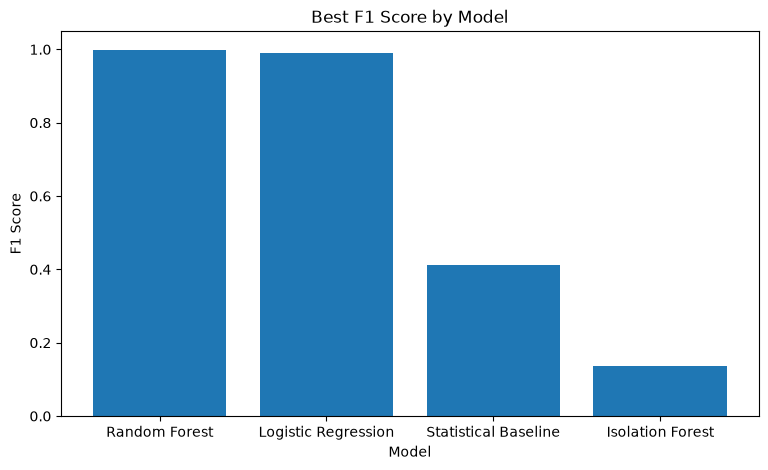

In [15]:
import matplotlib.pyplot as plt

# Sort models by F1 Score
plot_data = best_per_model.sort_values(
    by="F1",
    ascending=False
)

plt.figure(figsize=(9,5))

plt.bar(
    plot_data["Model"],
    plot_data["F1"]
)

plt.title("Best F1 Score by Model")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)

plt.show()

# Interpretation of Results

The comparison demonstrates a clear separation in performance between the supervised learning models and the remaining approaches.

Random Forest achieved the highest overall performance with an F1 Score of **0.998813**, closely followed by Logistic Regression with an F1 Score of **0.989121**. Both supervised learning models substantially outperformed the statistical rule based baseline, which achieved a best F1 Score of **0.412535**.

Isolation Forest produced the weakest overall performance, with a highest F1 Score of **0.137524**. Although Isolation Forest successfully identified some anomalous blocks, its performance was considerably lower than both supervised models and even the statistical baseline.

These results suggest that access to labeled training data provides a significant advantage for anomaly detection on the HDFS dataset. Both Logistic Regression and Random Forest were able to learn relationships within the engineered feature sets that could not be captured by the manually constructed statistical thresholds or by the unsupervised Isolation Forest algorithm.

Among all approaches evaluated, Random Forest produced the highest overall anomaly detection performance and is therefore selected as the best performing model in this study.

# Impact of Feature Engineering

One objective of this study was to determine whether progressively adding engineered features improved anomaly detection performance. Four feature sets were evaluated for each model, beginning with simple event occurrence counts and gradually incorporating two event sequences, three event sequences, and four event sequences.

The results indicate that the impact of feature engineering depended on the learning algorithm.

For the Statistical Baseline, adding sequential features consistently reduced the F1 Score. The best performance was achieved using Feature Set 1, suggesting that the additional sequence based features increased the number of threshold violations without improving the baseline's ability to distinguish between normal and anomalous blocks.

Logistic Regression showed gradual improvement as additional engineered features were introduced, achieving its highest F1 Score of **0.989121** using Feature Set 4. This suggests that the linear classifier was able to benefit from the richer feature representation.

Random Forest achieved its highest F1 Score using Feature Set 2, while Feature Sets 3 and 4 produced slightly lower performance. This indicates that introducing simple two event sequence features improved classification, but additional higher order sequence features provided little additional benefit.

Isolation Forest showed inconsistent behavior across the four feature sets. Although Feature Set 3 produced its highest F1 Score, the overall performance remained substantially lower than both supervised learning models. This suggests that increasing feature complexity alone was not sufficient to improve the performance of the unsupervised approach.

Overall, the results demonstrate that feature engineering can improve anomaly detection performance, but the effectiveness of additional engineered features depends on the learning algorithm. More complex feature representations did not universally produce better results across all models.

# Results Comparison Summary

This notebook combined the evaluation results from the statistical rule based baseline, Logistic Regression, Random Forest, and Isolation Forest into a unified comparison.

Among all models evaluated, Random Forest achieved the highest overall performance with an F1 Score of **0.998813**, followed closely by Logistic Regression with an F1 Score of **0.989121**. Both supervised learning approaches substantially outperformed the statistical baseline and the unsupervised Isolation Forest model.

The comparison also demonstrated that the effect of feature engineering depended on the learning algorithm. Additional sequence based features improved Logistic Regression, provided only modest benefit to Random Forest, reduced the effectiveness of the statistical baseline, and did not consistently improve Isolation Forest.

These findings suggest that supervised machine learning methods are considerably more effective than both manually constructed statistical thresholds and unsupervised anomaly detection for the HDFS dataset. Furthermore, carefully designed engineered features can improve performance, although increasing feature complexity does not guarantee better results.

The results presented in this notebook provide the final experimental evidence used to answer the research question and will serve as the foundation for the analysis and discussion presented in the final research paper.